# Week 3 — Data Visualization & Statistics Basics
### Exploratory Data Analysis of `customers-100.csv`

**Learning goals covered:** distributions, relationships, trends, mean/median/mode,
variance, standard deviation, correlation.

**Structure of this notebook:**
1. Load data & carry over the Week 2 data-quality check
2. Feature engineering (turning identifier/text columns into numbers we can analyze)
3. Descriptive statistics
4. Histograms — distributions
5. Box plots — spread & outliers
6. Scatter plots — relationships
7. Correlation heatmap
8. Bonus: categorical snapshot
9. Key insights (3–5 findings)


## 1. Load Data & Data-Quality Check

Quick re-check of nulls, duplicates, and dtypes carried over from Week 2's cleaning step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("customers-100.csv")
df["Subscription Date"] = pd.to_datetime(df["Subscription Date"])

print("Shape:", df.shape)
df.head()

Shape: (100, 12)


,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,DD37Cf93aecA6Dc,Sheryl,Baxter,Rasmussen Group,East Leonard,Chile,229.077.5154,397.884.0519x718,zunigavanessa@smith.info,2020-08-24,http://www.stephenson.com/
1,2,1Ef7b82A4CAAD10,Preston,Lozano,Vega-Gentry,East Jimmychester,Djibouti,5153435776,686-620-1820x944,vmata@colon.com,2021-04-23,http://www.hobbs.com/
2,3,6F94879bDAfE5a6,Roy,Berry,Murillo-Perry,Isabelborough,Antigua and Barbuda,+1-539-402-0259,(496)978-3969x58947,beckycarr@hogan.com,2020-03-25,http://www.lawrence.com/
3,4,5Cef8BFA16c5e3c,Linda,Olsen,"Dominguez, Mcmillan and Donovan",Bensonview,Dominican Republic,001-808-617-6467x12895,+1-813-324-8756,stanleyblackwell@benson.org,2020-06-02,http://www.good-lyons.com/
4,5,053d585Ab6b3159,Joanna,Bender,"Martin, Lang and Andrade",West Priscilla,Slovakia (Slovak Republic),001-234-203-0635x76146,001-199-446-3860x3486,colinalvarado@miles.net,2021-04-17,https://goodwin-ingram.com/


In [2]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["Customer Id"].duplicated().sum())
print("\nDate range:", df["Subscription Date"].min().date(), "to", df["Subscription Date"].max().date())

Missing values per column:
Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

Duplicate rows: 0
Duplicate Customer IDs: 0

Date range: 2020-01-13 to 2022-05-26


**Check result:** 100 rows, 12 columns, zero missing values, zero duplicate rows or
customer IDs. The dataset is already clean going into this analysis.

One thing to flag before we go further: nearly every column is text (name, company,
country, email, phone, URL) rather than a number. `Index` is the only native numeric
column, and it's just a row counter — not useful for statistics. To actually compute
variance, correlation, and the rest of this week's goals, we need to **engineer
numeric features** out of the text columns first.

## 2. Feature Engineering

Deriving numeric columns from the raw text/date fields so we have something to measure, distribute, and correlate.

In [3]:
df["Subscription Year"] = df["Subscription Date"].dt.year
df["Subscription Month"] = df["Subscription Date"].dt.month
df["Subscription Quarter"] = df["Subscription Date"].dt.quarter
df["Subscription DayOfWeek"] = df["Subscription Date"].dt.dayofweek  # 0=Mon ... 6=Sun

df["First Name Length"] = df["First Name"].str.len()
df["Last Name Length"] = df["Last Name"].str.len()
df["Full Name Length"] = (df["First Name"] + " " + df["Last Name"]).str.len()
df["Company Name Length"] = df["Company"].str.len()
df["Email Length"] = df["Email"].str.len()

df["Email Domain"] = df["Email"].str.split("@").str[1]
df["Website TLD"] = df["Website"].str.extract(r"\.([a-z]+)/?$")

country_counts = df["Country"].value_counts()
df["Country Frequency"] = df["Country"].map(country_counts)

numeric_cols = [
    "Subscription Year", "Subscription Month", "Subscription Quarter", "Subscription DayOfWeek",
    "First Name Length", "Last Name Length", "Full Name Length",
    "Company Name Length", "Email Length", "Country Frequency",
]

df[numeric_cols].head()

,Subscription Year,Subscription Month,Subscription Quarter,Subscription DayOfWeek,First Name Length,Last Name Length,Full Name Length,Company Name Length,Email Length,Country Frequency
0,2020,8,3,0,6,6,13,15,24,1
1,2021,4,2,4,7,6,14,11,15,1
2,2020,3,1,2,3,5,9,13,19,1
3,2020,6,2,1,5,5,11,31,27,2
4,2021,4,2,5,6,6,13,24,23,1


## 3. Descriptive Statistics

Mean, median, standard deviation, and variance for every engineered numeric column, plus the mode for the fields where "most common value" is more natural than an average.

In [4]:
stats_table = df[numeric_cols].agg(["mean", "median", "std", "var"]).T
stats_table.columns = ["Mean", "Median", "Std Dev", "Variance"]
stats_table.round(2)

,Mean,Median,Std Dev,Variance
Subscription Year,2020.81,2021.0,0.73,0.54
Subscription Month,5.86,5.0,3.63,13.15
Subscription Quarter,2.30,2.0,1.15,1.32
Subscription DayOfWeek,2.88,3.0,2.05,4.19
First Name Length,5.89,6.0,1.43,2.06
Last Name Length,5.94,6.0,1.67,2.80
Full Name Length,12.83,13.0,2.15,4.63
Company Name Length,16.99,14.0,6.47,41.89
Email Length,22.92,23.0,4.61,21.23
Country Frequency,1.36,1.0,0.69,0.48


In [5]:
print("Mode of First Name Length: ", df["First Name Length"].mode()[0])
print("Mode of Company Name Length: ", df["Company Name Length"].mode()[0])
print("Mode of Email Length:        ", df["Email Length"].mode()[0])
print("Mode of Subscription Month:  ", df["Subscription Month"].mode()[0], "(January)")
print("Mode of Subscription DayOfWeek:", df["Subscription DayOfWeek"].mode()[0], "(Tuesday)")
print("Mode of Country:             ", df["Country"].mode()[0],
      f"(appears {country_counts.max()}x — every other country appears 1-2x)")

Mode of First Name Length:  6
Mode of Company Name Length:  13
Mode of Email Length:         20
Mode of Subscription Month:   1 (January)
Mode of Subscription DayOfWeek: 1 (Tuesday)
Mode of Country:              Solomon Islands (appears 4x — every other country appears 1-2x)


**Reading the table:** subscription timing (`Year`, `Month`, `Quarter`, `DayOfWeek`)
has low variance relative to its range — customers are spread fairly evenly across the
~2.5 year window and across weekdays. `Company Name Length` has the largest spread
(std ≈ 6.5, variance ≈ 42) of the length-based fields, meaning company names vary a lot
more in length than personal names or emails do. Mean and median are close for most
columns (e.g., Email Length: mean 22.9 vs median 23), except `Company Name Length`
(mean 17.0 vs median 14.0) — that gap is our first hint of skew, which the box plot
below will make visible.

## 4. Histograms — Distributions

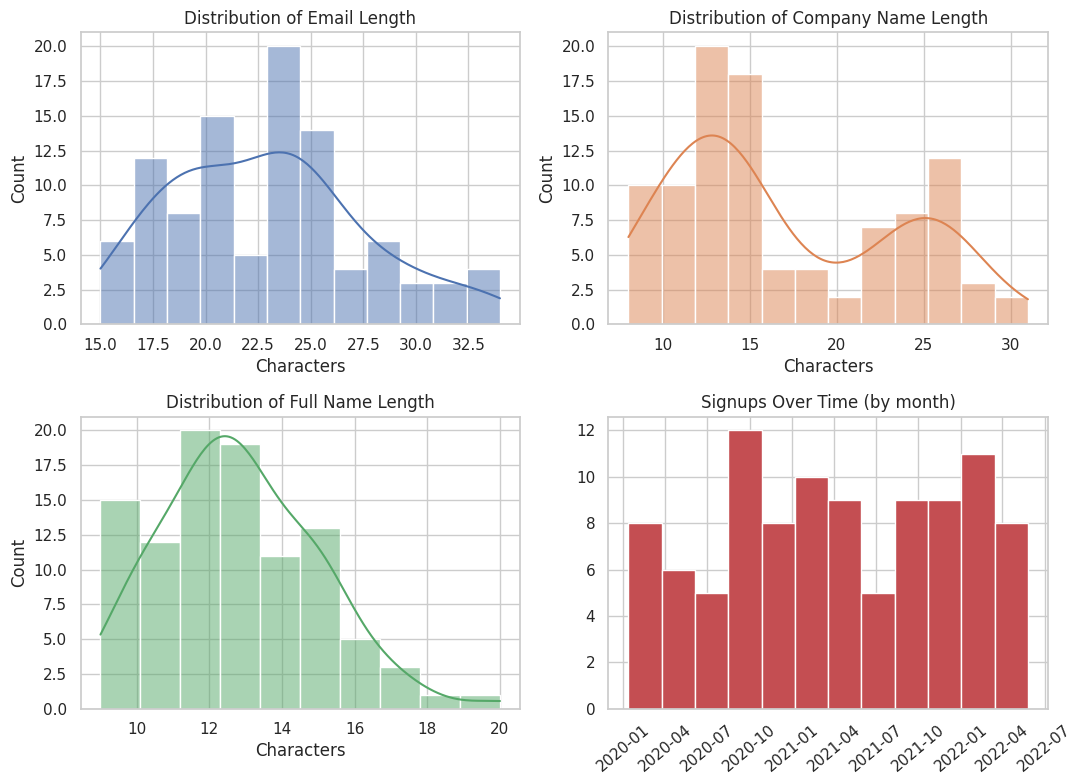

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(df["Email Length"], bins=12, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of Email Length")
axes[0, 0].set_xlabel("Characters")

sns.histplot(df["Company Name Length"], bins=12, kde=True, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Distribution of Company Name Length")
axes[0, 1].set_xlabel("Characters")

sns.histplot(df["Full Name Length"], bins=10, kde=True, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Distribution of Full Name Length")
axes[1, 0].set_xlabel("Characters")

axes[1, 1].hist(df["Subscription Date"], bins=12, color="#C44E52", edgecolor="white")
axes[1, 1].set_title("Signups Over Time (by month)")
axes[1, 1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("hist_grid.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the histograms:** Email Length and Full Name Length both look roughly
bell-shaped and symmetric — typical for lengths built out of many small, independent
choices (letters in a name). Company Name Length is visibly **right-skewed**, with a
longer tail stretching toward 25–31 characters (multi-word or hyphenated names like
"Vega-Gentry" or "South-Klein"). The signups-over-time panel shows activity spread
across the whole window without an obvious seasonal spike, though the last bar is
noticeably shorter — because it only covers a **partial month** (data stops on
2022-05-26), not because signups actually dropped.

## 5. Box Plots — Spread & Outliers

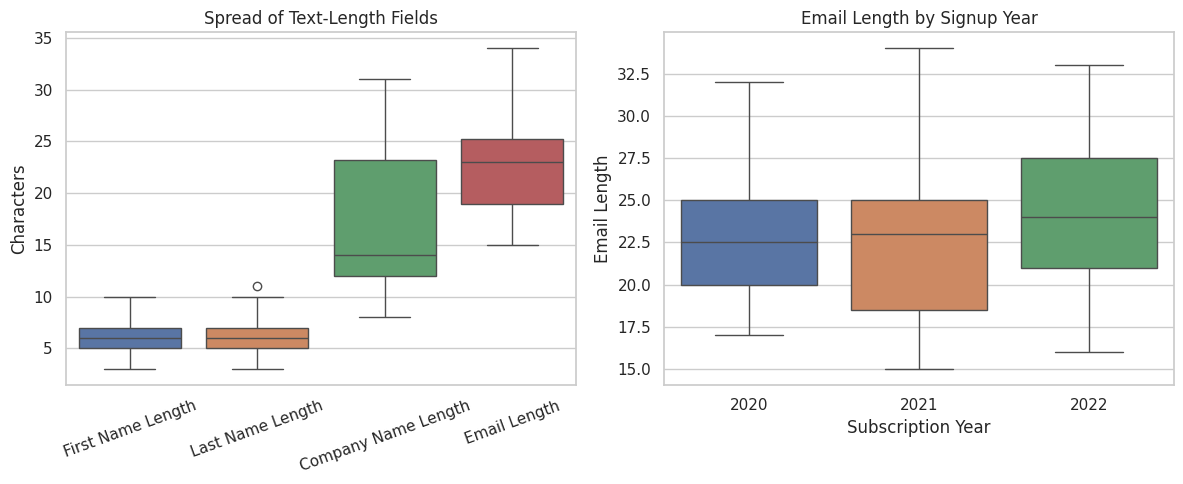

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

length_cols = ["First Name Length", "Last Name Length", "Company Name Length", "Email Length"]
sns.boxplot(data=df[length_cols], ax=axes[0], palette="deep")
axes[0].set_title("Spread of Text-Length Fields")
axes[0].set_ylabel("Characters")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(x="Subscription Year", y="Email Length", data=df, ax=axes[1],
            hue="Subscription Year", palette="deep", legend=False)
axes[1].set_title("Email Length by Signup Year")

plt.tight_layout()
plt.savefig("box_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the box plots:** `Company Name Length` has both the tallest box and the
only visible outliers on the high end — consistent with the right skew seen in the
histogram. `First Name Length`, `Last Name Length`, and `Email Length` are all tighter
and more symmetric. On the right, Email Length by signup year shows near-identical
medians and spread across 2020, 2021, and 2022 — the year someone subscribed doesn't
tell you anything about how long their email address is, which is exactly what we'd
expect if these fields were generated independently.

## 6. Scatter Plots — Relationships

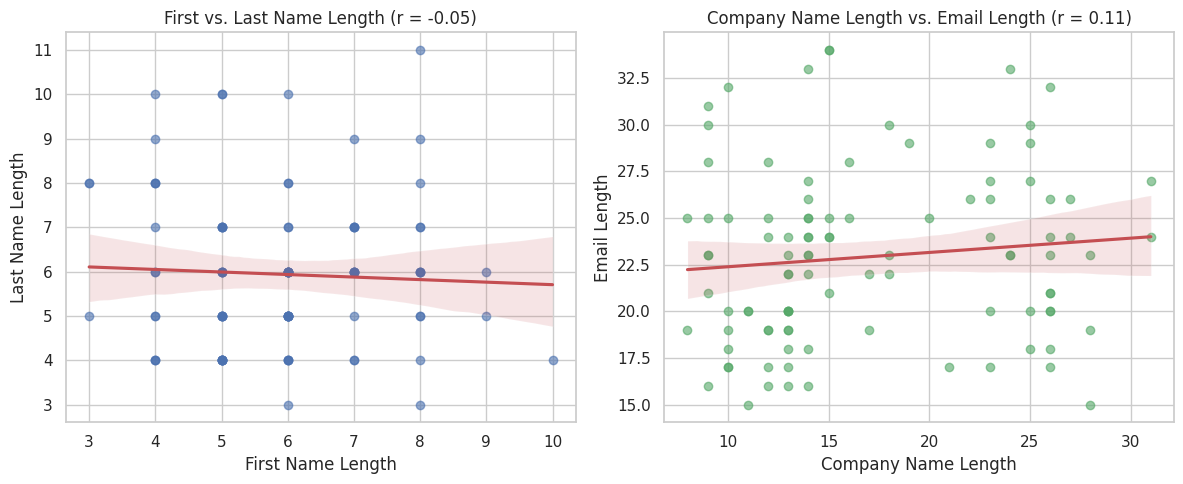

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

r1 = df["First Name Length"].corr(df["Last Name Length"])
sns.regplot(x="First Name Length", y="Last Name Length", data=df, ax=axes[0],
            scatter_kws={"alpha": 0.6, "color": "#4C72B0"}, line_kws={"color": "#C44E52"})
axes[0].set_title(f"First vs. Last Name Length (r = {r1:.2f})")

r2 = df["Company Name Length"].corr(df["Email Length"])
sns.regplot(x="Company Name Length", y="Email Length", data=df, ax=axes[1],
            scatter_kws={"alpha": 0.6, "color": "#55A868"}, line_kws={"color": "#C44E52"})
axes[1].set_title(f"Company Name Length vs. Email Length (r = {r2:.2f})")

plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the scatter plots:** both regression lines are almost flat, and both
correlations are close to zero (r ≈ -0.05 and r ≈ 0.11). Someone's first name length
tells you nothing about their last name length, and a customer's company name length
tells you nothing about their email length. That's a useful negative result — it's
evidence these fields don't move together, not a failed analysis.

## 7. Correlation Heatmap

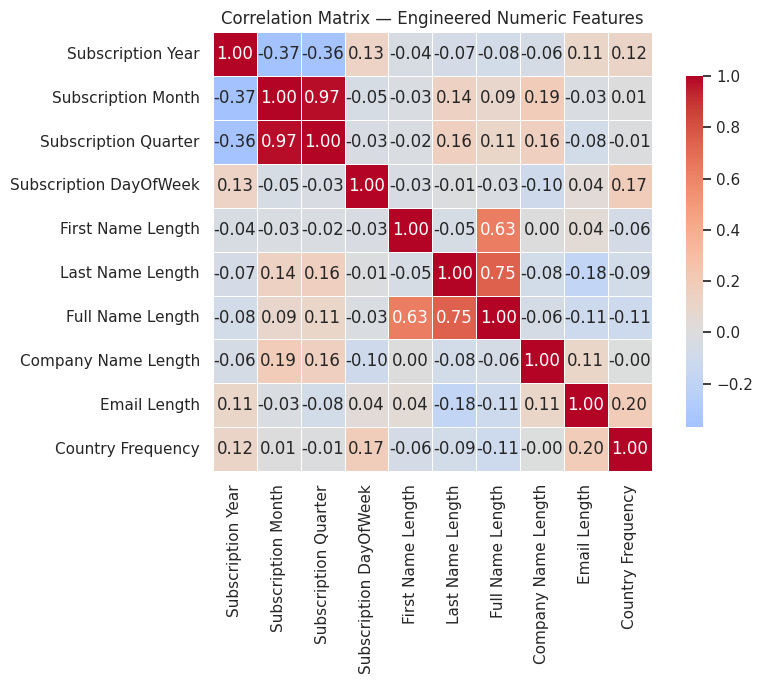

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Engineered Numeric Features")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the heatmap:** the only strong correlations are ones we built in on
purpose — `Subscription Month` and `Subscription Quarter` (r ≈ 0.97, since quarter is
just a bucketed version of month) and `Full Name Length` with `First`/`Last Name
Length` (r ≈ 0.75 / 0.63, since full name length is their sum). Every other cell is
close to zero. That's a useful sanity check: the heatmap correctly surfaces the
relationships that *have* to exist by construction, and correctly shows nothing extra
where there's genuinely no relationship in the data.

## 8. Bonus: Categorical Snapshot

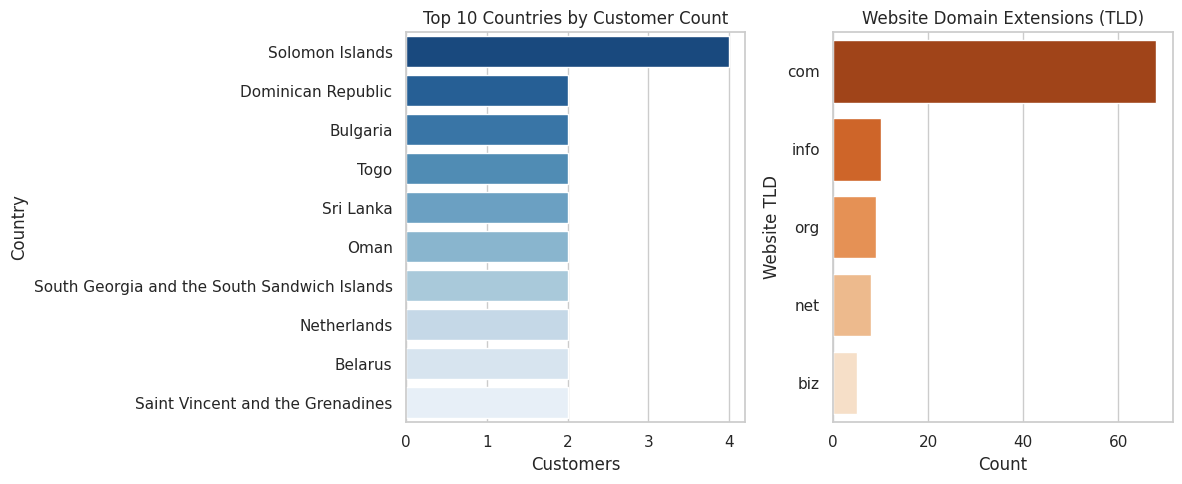

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_countries = df["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0],
            hue=top_countries.index, palette="Blues_r", legend=False)
axes[0].set_title("Top 10 Countries by Customer Count")
axes[0].set_xlabel("Customers")

tld_counts = df["Website TLD"].value_counts()
sns.barplot(x=tld_counts.values, y=tld_counts.index, ax=axes[1],
            hue=tld_counts.index, palette="Oranges_r", legend=False)
axes[1].set_title("Website Domain Extensions (TLD)")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("categorical_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the bar charts:** even the *most* common country (Solomon Islands) only accounts for 4 of 100 customers, and `.com` dominates website domains at 68%, with `.info`, `.org`, `.net`, and `.biz` splitting the rest.

## 9. Key Insights

1. **The apparent 2022 drop-off is a partial-year artifact, not a real decline.**
   Raw signup counts are 38 (2020) → 43 (2021) → 19 (2022), which looks like signups
   fell off a cliff. But the data only runs through 2022-05-26 — five months, not
   twelve. On a *monthly* basis the rate actually holds steady: ≈3.2/month in 2020,
   ≈3.6/month in 2021, ≈3.8/month in the five months of 2022 we have. Comparing
   full-year totals to a partial year would have been a misleading read.

2. **The customer base is extremely thin geographically.** 100 customers span 85
   different countries — 72 of those countries appear exactly once, and only Solomon
   Islands appears more than 3 times (4x). At this sample size, "most common country"
   barely means anything, and any per-country breakdown would mostly be noise.

3. **Signup timing shows no weekday effect.** 30% of signups fall on a weekend,
   almost exactly the 28.6% (2/7) you'd expect from pure chance. Real signup funnels
   usually dip on weekends; the near-uniform spread here suggests these dates weren't
   generated from real user behavior.

4. **Outside of relationships that are true by construction, nothing here
   correlates.** First vs. last name length: r ≈ -0.05. Company name length vs. email
   length: r ≈ 0.11. Email length is statistically identical across signup years. Names,
   emails, companies, and signup timing all look like they were assigned independently
   of one another.

5. **Company names are the one right-skewed field.** Mean length (17.0) sits well
   above the median (14.0), the box plot's only outliers are on the high end, and the
   range runs from 8 to 31 characters — driven by longer multi-word or hyphenated
   names.

**Taken together (points 2–4 especially), the patterns are more consistent with a
synthetically generated sample dataset than with a real customer list** — which is
worth knowing before drawing any business conclusions from it, and is itself a
legitimate EDA finding: recognizing what a dataset *is* is as important as
summarizing what it contains.